# Uncorrelated a-b RMSE: DQN (normal) vs MFI

`EXP007/data/uncorrelated_ab_rmse_dqn_normal_mfi.csv` を読み込み、テスト長ごとのRMSEを比較する。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "EXP007" / "data" / "uncorrelated_ab_rmse_dqn_normal_mfi.csv").exists():
            return path
    raise FileNotFoundError("Could not find project root containing EXP007/data/uncorrelated_ab_rmse_dqn_normal_mfi.csv")


ROOT = find_project_root(Path.cwd())
DATA_PATH = ROOT / "EXP007" / "data" / "uncorrelated_ab_rmse_dqn_normal_mfi.csv"
FIG_PATH = ROOT / "EXP007" / "data" / "uncorrelated_ab_rmse_dqn_normal_mfi.png"

df = pd.read_csv(DATA_PATH)
df

,Test length,DQN (normal),MFI
0,10,0.415,0.493
1,20,0.278,0.331
2,30,0.244,0.277
3,40,0.227,0.245


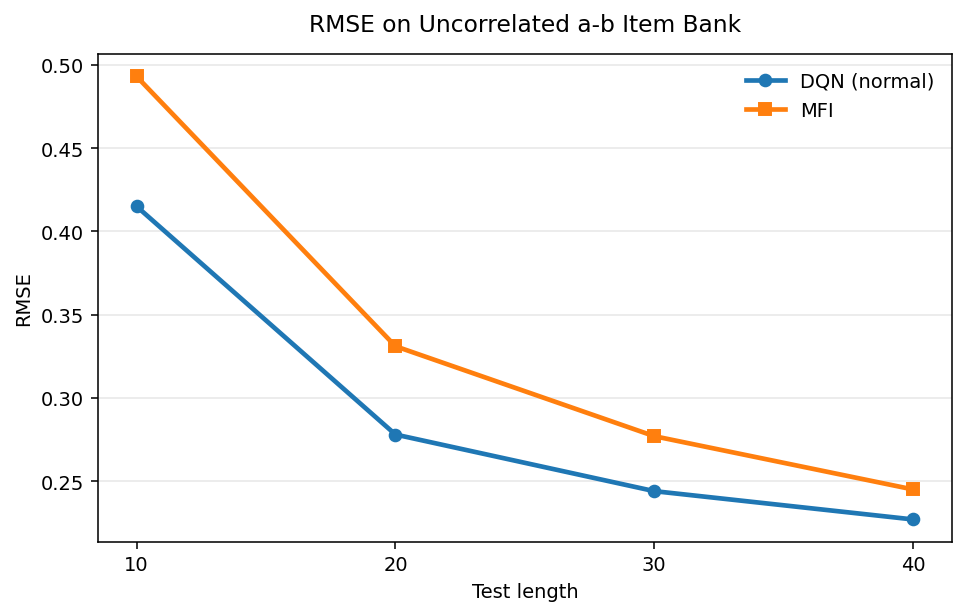

Saved figure to: /home/ituki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP007/data/uncorrelated_ab_rmse_dqn_normal_mfi.png


In [2]:
plot_df = df.copy()
plot_df["Test length"] = pd.to_numeric(plot_df["Test length"])
plot_df["DQN (normal)"] = pd.to_numeric(plot_df["DQN (normal)"])
plot_df["MFI"] = pd.to_numeric(plot_df["MFI"])

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=140)

ax.plot(
    plot_df["Test length"],
    plot_df["DQN (normal)"],
    marker="o",
    linewidth=2.4,
    label="DQN (normal)",
)
ax.plot(
    plot_df["Test length"],
    plot_df["MFI"],
    marker="s",
    linewidth=2.4,
    label="MFI",
)

ax.set_title("RMSE on Uncorrelated a-b Item Bank", pad=12)
ax.set_xlabel("Test length")
ax.set_ylabel("RMSE")
ax.set_xticks(plot_df["Test length"])
ax.grid(True, axis="y", alpha=0.3)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(FIG_PATH, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {FIG_PATH}")